## PyTorch 

### 파이토치 설치



In [1]:
# 설치확인
import torch

In [3]:
# 파이토치 버전확인
torch.__version__

'2.12.0+cu126'

In [5]:
# GPU 사용가능(가속실행) 여부 확인
torch.cuda.is_available()

True

In [127]:
# OpenCV 포함하기
import cv2
cv2.__version__

'4.13.0'

In [128]:
# OpenCV GPU 가속여부 확인
cv2.cuda.getCudaEnabledDeviceCount()

0

### 파이토치 기본

- 텐서(Tensor) 개념
    - 딥러닝 모델을 만들때 가장 기본이 되는 구조
    - 숫자를 담는 다차원 배열
    - 수학에서 사용하는 행렬(Matrix)를 일반화한 구조

- 텐서의 종류
    - 스칼라 : 0차원 텐서(`5`) 
    - 벡터 : 1차원 텐서(`[1, 3, 5, 7, 9]`)
    - 행렬 : 2차원 텐서(`[[1, 2], [3, 4]]`)
    - 텐서 : n차원 텐서. 딥러닝에서 흔히 다루는 데이터 구조

    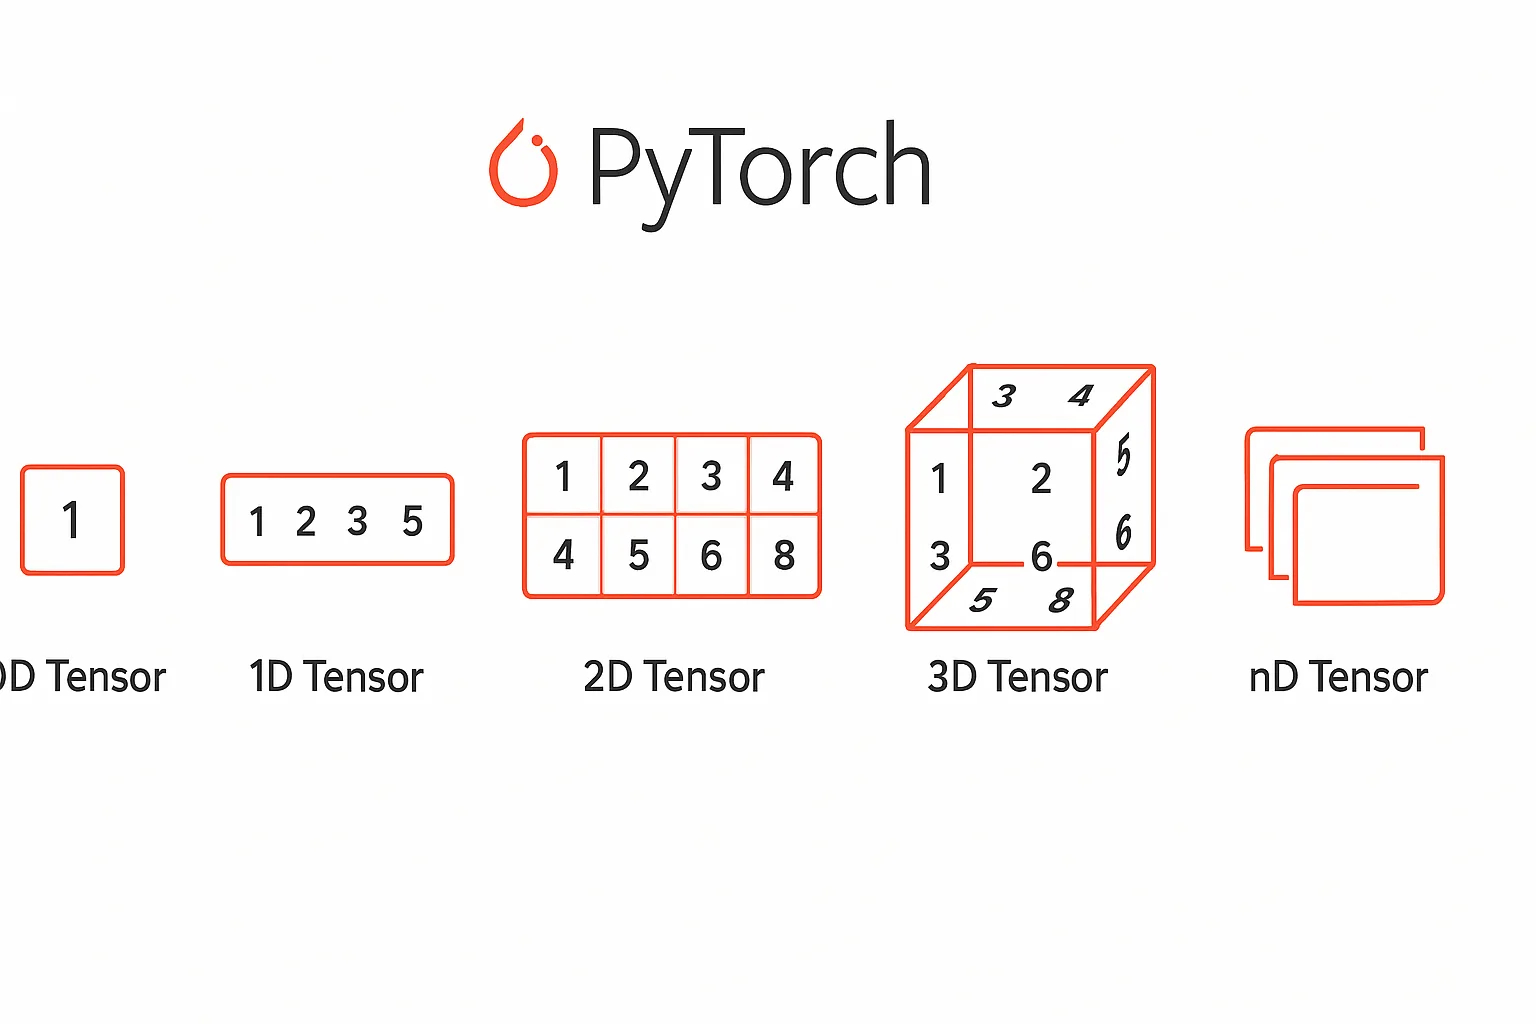

In [36]:
# 텐서 만들기
## 스칼라(0차원 텐서) 생성
x = torch.tensor(5)

print(x)
print(x.dim())  # 텐서 차원수 확인

tensor(5)
0


In [39]:
## 벡터(1차원 텐서) 생성
x = torch.tensor([1,3,5,7,9])

print(x)
print(x.dim())

tensor([1, 3, 5, 7, 9])
1


In [41]:
## 행렬,매트릭스(2차원 텐서) 생성
# x = torch.tensor([[1, 2],[3, 4]])  # int64
x = torch.tensor([[1.0, 2.2], [3.4, 4.1]])  # float32

print(x)
print(x.dim())

tensor([[1.0000, 2.2000],
        [3.4000, 4.1000]])
2


In [43]:
## 3차원 텐서 생성
x = torch.tensor([[[1,2,3],[4,5,6],[7,8,9]],[[10,11,12],[13,14,15],[16,17,18]],[[19,20,21],[22,23,24],[25,26,27]]])

print(x)
print(x.dim())

tensor([[[ 1,  2,  3],
         [ 4,  5,  6],
         [ 7,  8,  9]],

        [[10, 11, 12],
         [13, 14, 15],
         [16, 17, 18]],

        [[19, 20, 21],
         [22, 23, 24],
         [25, 26, 27]]])
3


In [37]:
# 텐서 속성 확인
x.dtype # 텐서 데이터 타입

torch.int64

In [46]:
# 텐서크기  [] 0차원 [3] 1차원 [2,2] 2차원 [3,2,1] 3차원
x.shape

torch.Size([3, 3, 3])

In [48]:
# 텐서가 위치한 장치 확인 (cpu 또는 gpu)
x.device

device(type='cpu')

#### 정리
- torch.tensor 의 인자(파라미터)로 파이썬 리스트나 넘파이 배열을 넣을 수 있음

#### 많이 사용되는 텐서 함수
- 같은 크기의 다른 텐서를 사용 중
- 같은 크기로 초기화하는 텐서를 만들기 위해서

In [49]:
# 모든 원소가 0인 텐서 만들기
t_zeros = torch.zeros(2, 3) # 2x3 짜리 매트릭스 생성
t_zeros

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [ ]:
# 사이즈 신경쓰지 않고 같은 크기의 텐서를 만들때
t_zeros2 = torch.zeros_like(t_zeros)
t_zeros2

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [51]:
# 모든 원소가 1인 텐서
t_ones = torch.ones(2, 3)
t_ones

tensor([[1., 1., 1.],
        [1., 1., 1.]])

In [52]:
# 0~1 사이의 균등분포를 가지는 랜덤 텐서 만들기
t_randoms = torch.rand(2, 3)
t_randoms

tensor([[0.4676, 0.5559, 0.5057],
        [0.8094, 0.0529, 0.3846]])

#### 텐서연산

- 사칙연산, 곱셉, 전치... 여러 연산방법 제공

In [ ]:
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([[5, 6], [7, 8]])

# 덧셈
print(x + y)     # 일반적 연산자
print(torch.add(x, y)) # 파이토치 연산함수

tensor([[ 6,  8],
        [10, 12]])
tensor([[ 6,  8],
        [10, 12]])


In [62]:
# 뺄셈
print(x - y)
print(torch.subtract(x, y))

tensor([[-4, -4],
        [-4, -4]])
tensor([[-4, -4],
        [-4, -4]])


In [65]:
# 곱셈 (원소별 곱셈)
print(x * y)
print(torch.mul(x, y))

tensor([[ 5, 12],
        [21, 32]])
tensor([[ 5, 12],
        [21, 32]])


In [68]:
# 행렬곱셈
print(x @ y)
print(torch.matmul(x, y))

tensor([[19, 22],
        [43, 50]])
tensor([[19, 22],
        [43, 50]])


- 브로드캐스팅(BoardCasting) : 크기가 다른 텐서 간의 연산

In [71]:
# x = [[1,2],[3,4]] 
scalar = 10

print(x + scalar)

tensor([[11, 12],
        [13, 14]])


- 인덱싱, 슬라이싱 : 하나의 요소 접근, 필요요소만 자라내기


In [73]:
x = torch.tensor([[10,20,30],
                  [40,50,60],
                  [70,80,90]])
print(x)

tensor([[10, 20, 30],
        [40, 50, 60],
        [70, 80, 90]])


In [76]:
# 2행 3열의 값을 조회
x[1, 2]

tensor(60)

In [78]:
# 1행 모든 열 원소 슬라이싱
x[0, :]

tensor([10, 20, 30])

In [80]:
# 2열의 모든 원소 슬라이싱
x[:, 1]

tensor([20, 50, 80])

In [85]:
# 1행~2행까지, 2열~3열까지 슬라이싱
x[0:2, 1:]

tensor([[20, 30],
        [50, 60]])

#### 문제

1. 2행 4열의 모든 원소가 9인 텐서 c를 만드시오
2. 두 텐서 a, b를 정의하고, 둘의 더한 결과를 출력하시오
    ```python
    a = [1,2,3]
    b = [4,8,10]    
    ```
3. 텐서 x에서 6과 90만 선택해서 새 텐서 y를 만드시오
    ```python
    x = [[1, 2, 3], 
         [4, 5, 6],
         [70, 80, 90]]
    ```
4. 텐서 m과 n의 행렬곱셈 결과를 출력하시오
    ```python
    m = [[1, 3], [5, 7]]
    n = [[1, 0], [0, 1]]
    ```

In [94]:
# 문제 1
c = torch.ones(2, 4)
print(c * 9)

tensor([[9., 9., 9., 9.],
        [9., 9., 9., 9.]])


In [133]:
# 정해진 사이즈의 텐서를 해당값으로 채우기
c = torch.full((2, 4), 9)
c

tensor([[9, 9, 9, 9],
        [9, 9, 9, 9]])

In [97]:
# 문제 2
a = torch.tensor([1, 2, 3] )
b = torch.tensor( [4, 8, 10])
a + b

tensor([ 5, 10, 13])

In [103]:
# 문제 3
x = torch.tensor( [[1, 2, 3], 
           [4, 5, 6],
           [70, 80, 90]])
print(x)
 
y = torch.tensor([x[1, 2], x[2, 2]])   # 인덱싱
print(y) # 벡터

tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [70, 80, 90]])
tensor([ 6, 90])


In [ ]:
# 문제 4
m = torch.tensor([[1, 3], [5, 7]])
n = torch.tensor([[1, 0], [0, 1]])  # 단위행렬

# m @ n
torch.matmul(m, n)

tensor([[1, 3],
        [5, 7]])

In [110]:
# 0부터 9까지
torch.arange(0, 10)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### PyTorch와 Numpy 공통점
- 넘파이와 파이토치의 배열은 거의 동일
- 둘 다 다차원 배열 처리 가능
- 연산도 거의 동일
- 문법도 거의 동일
- Numpy에 익숙하면 PyTorch도 금새 익숙해짐

In [112]:
import numpy as np

In [122]:
# Numpy data
n_array = np.array([1,3,5,7,9])
print(n_array)  # print문을 사용하면 array() 표시가 사라짐

# Tensor data
t_array = torch.tensor([2,4,6,8,10])
print(t_array)

[1 3 5 7 9]
tensor([ 2,  4,  6,  8, 10])


In [126]:
# 텐서가 어디에 저장되어 있는지 확인
t_array.device

device(type='cpu')

In [118]:
n_array

array([1, 3, 5, 7, 9])

In [123]:
# 넘파이 배열은 파이토치 텐서로 변경 가능
# numpy -> tensor 변경 가능
t_array_f_np = torch.from_numpy(n_array)
t_array_f_np

tensor([1, 3, 5, 7, 9])

In [124]:
# 텐서를 넘파이 데이터로 변경
# tensor -> numpy 변경 가능
t_array_f_np.numpy()

array([1, 3, 5, 7, 9])

#### 텐서와 넘파이 차이점

1. GPU 지원
    - 파이토치는 GPU 사용해서 연산속도를 크게 높일 수 있음
    - CPU 사용때보다 병렬연산이 많이 필요
    - Numpy 경우는 GPU를 사용하려면 CuPy라이브러리를 사용해야
    - 순차적인 소량 작업은 CPU가 더 빠름. 수천개의 코어로 병렬작업시는 GPU 효과적

2. 자동미분 지원
    - 텐서로 미분값을 자동 계산해주는 기능. Autograd 내장
    - 딥러닝 모델 학습시 경사하강법 구현 때 사용
    - Numpy는 직접 미분값을 계산


#### 결론
- 넘파이와 동일한 강력한 다차원 배열 지원, 딥러닝에 필수인 GPU가속과 자동미분 기능을 제공

#### 많이 쓰이는 분야
1. 생성형 AI / LLM
2. 컴퓨터 비전 - YOLO
3. 자연어 처리(NLP)
4. 음성 AI
5. Physical AI
6. 강화학습(RL)
7. 의료/바이오 AI

- 생성형 AI 이후로 Tensorflow에서 PyTorch로 많이 이전되는 상황

